In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotion'])
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [3]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [4]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
for i, emotion in enumerate(unique_emotions):
    emotion_numbers[emotion] = i
emotion_numbers

df['emotion'] = df['emotion'].map(emotion_numbers)

Text(0.5, 1.0, 'Distribution of Emotions in the Dataset')

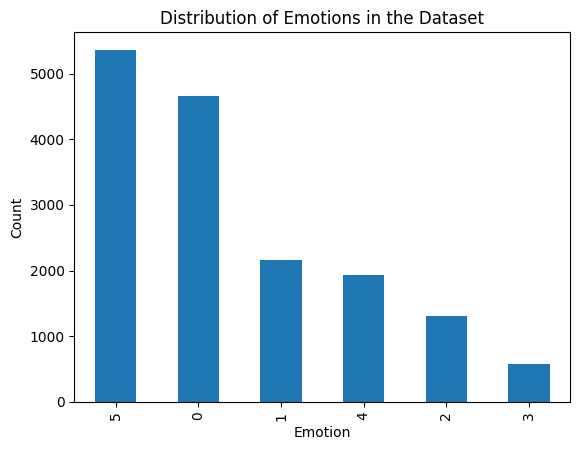

In [5]:
df['emotion'].value_counts().plot(kind='bar')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Emotions in the Dataset')

In [6]:
# 1. Convert into Lowercase
df['text'] = df['text'].apply(lambda x : x.lower())
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [7]:
# Remove Punctuation
import string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [8]:
df['text'] = df['text'].apply(remove_punctuation)

In [9]:
# Remove Number
def remove_number(text):
    new = ""
    for i in text:
      if not i.isdigit():
        new = new + i
    return new

df['text'] = df['text'].apply(remove_number)
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [10]:
# Remove URL
import neattext.functions as nfx
df['text'] = df['text'].apply(nfx.remove_urls)
df.head()

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1


In [11]:
# Remove emoji
import emoji

def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")

df['text'] = df['text'].apply(remove_emoji)

In [12]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Load stopwords and convert to a SET for faster processing
stop_words = set(stopwords.words('english'))

# 2. Create a function to process a single string
def remove_stopwords(text):
    words = word_tokenize(text)
    # Filter out stopwords
    filtered_words = [word for word in words if word.lower() not in stop_words]

    # Join the words back into a single string
    return " ".join(filtered_words)
df['text'] = df['text'].apply(remove_stopwords)

[nltk_data] Downloading package punkt_tab to C:\Users\Arin
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Arin
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [14]:
df.head()

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2, random_state=42)


In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)


nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)


pred_bow = nb_model.predict(X_test_bow)
print(accuracy_score(y_test, pred_bow))

0.7678125


In [17]:
pred_bow

array([0, 5, 0, ..., 5, 5, 0], shape=(3200,))

In [18]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [19]:
nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [20]:
y_pred = nb2_model.predict(X_test_tfidf)
print(accuracy_score(y_test, y_pred))

0.700625


In [21]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(class_weight='balanced', max_iter=1000)
logistic_model.fit(X_train_tfidf,y_train)
log_pred = logistic_model.predict(X_test_tfidf)
print(accuracy_score(y_test,log_pred ))

0.8990625


In [22]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(accuracy_score(y_test, y_pred_svm))

0.9040625


In [23]:
import joblib
joblib.dump(svm_model, 'model.pkl')
joblib.dump(tfidf_vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']